In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
# import countrycode

import geopandas as gpd

from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

ERROR 1: PROJ: proj_create_from_database: Open of /home/lhasbini/.conda/envs/dev/share/proj failed


In [18]:
model = "meta-llama/llama-4-scout-17b-16e-instruct"
MODEL_NAME = model
nb_rep = 50
res_savename = f"llm_response_impact_test_range_hazmain_nb_format_std_units_cont_units_{nb_rep}rep_{MODEL_NAME.replace('/', '_')}"#.csv"
# res_savename = f"llm_response_hazmain_nb_format_std_units_impact_{nb_rep}rep_test_{MODEL_NAME.replace('/', '_')}"#.csv"
print(res_savename)
response_df = pd.read_csv(DATA_OUT_LLMS + res_savename+".csv")
# response_df["location"] = response_df["location"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else [x])

llm_response_impact_test_range_hazmain_nb_format_std_units_cont_units_50rep_meta-llama_llama-4-scout-17b-16e-instruct


In [38]:
# Education : 
edu_df = response_df[response_df['impactSubtype'].isin(['Education Infrastructure', 'Access to Education'])]
grouped = edu_df.groupby('appealCode')['impactSubtype'].unique()
appeal_with_both = grouped[grouped.apply(lambda x: set(['Education Infrastructure', 'Access to Education']).issubset(set(x)))].index
num_appealCodes_with_both = len(appeal_with_both)

print("Number of appealCodes with both 'Education Infrastructure' subtypes:", response_df.loc[response_df.impactSubtype=='Education Infrastructure'].appealCode.nunique())
print("Number of appealCodes with both 'Access to Education' subtypes:", response_df.loc[response_df.impactSubtype=='Access to Education'].appealCode.nunique())
print("Number of appealCodes with both impact subtypes:", num_appealCodes_with_both)

Number of appealCodes with both 'Education Infrastructure' subtypes: 15
Number of appealCodes with both 'Access to Education' subtypes: 7
Number of appealCodes with both impact subtypes: 4


In [42]:
response_df.loc[(response_df.appealCode.isin(appeal_with_both)) & (response_df.impactSubtype.isin(['Education Infrastructure', 'Access to Education']))]['impactsAnnotation'].iloc[0]

"['Educational institutions were also impacted, with 24 schools affected by the flood.']"

In [39]:
response_df.loc[(response_df.appealCode.isin(appeal_with_both)) & (response_df.impactSubtype.isin(['Education Infrastructure', 'Access to Education']))]

,impactSubtype,impactValue,impactUnit,impactValueApprox,country,location,startYear,startMonth,startDay,endYear,...,endDay,hazards,impactsAnnotation,impactValueMin,impactValueMax,appealCode,country_kw,reportDate,disasterType,nathaz_text
181,Education Infrastructure,24.0,schools,exact,['Malaysia'],['Sabah'],2025.0,3.0,8.0,NaN,...,NaN,['Flood'],"['Educational institutions were also impacted,...",24.0,24.0,MDRMY012,Malaysia,2025-03-28 00:00:00,Flood,['(Photo:MRCS) Appeal: MDRMY012 Country: Malay...
184,Access to Education,NaN,NaN,NaN,['Malaysia'],['Sabah'],2025.0,3.0,8.0,NaN,...,NaN,['Flood'],"['Educational institutions were also impacted,...",NaN,NaN,MDRMY012,Malaysia,2025-03-28 00:00:00,Flood,['(Photo:MRCS) Appeal: MDRMY012 Country: Malay...
342,Education Infrastructure,27.0,infrastructures,exact,['Sierra Leone'],['multiple districts'],2024.0,9.0,23.0,NaN,...,NaN,['Flood'],['Heavy rainfall from Guinea triggered these f...,27.0,27.0,MDRSL016,Sierra Leone,2025-03-04 00:00:00,Flood,['DREF Operational Update Sierra Leone Floods ...
345,Access to Education,NaN,NaN,NaN,['Sierra Leone'],['multiple districts'],2024.0,9.0,23.0,NaN,...,NaN,['Flood'],['The flooding also rendered many roads impass...,NaN,NaN,MDRSL016,Sierra Leone,2025-03-04 00:00:00,Flood,['DREF Operational Update Sierra Leone Floods ...
398,Education Infrastructure,NaN,NaN,NaN,['Vanuatu'],['Port Vila'],2024.0,12.0,17.0,NaN,...,NaN,['Earthquake'],"['Port Vilas main hospital, schools, and2.0 ma...",NaN,NaN,MDRVU012,Vanuatu,2025-02-27 00:00:00,Earthquake,['SITUATION ANALYSIS Description of the crisis...
403,Access to Education,NaN,NaN,NaN,['Vanuatu'],['Port Vila'],2024.0,12.0,17.0,NaN,...,NaN,['Earthquake'],['The Education Cluster identified damage to s...,NaN,NaN,MDRVU012,Vanuatu,2025-02-27 00:00:00,Earthquake,['SITUATION ANALYSIS Description of the crisis...
412,Education Infrastructure,NaN,NaN,NaN,['Sudan'],['affected communities'],NaN,NaN,NaN,NaN,...,NaN,['Flood'],['Critical infrastructure has been severely da...,NaN,NaN,MDRSS014,Republic of South Sudan,2025-02-27 00:00:00,Flood,['SITUATION ANALYSIS Description of the crisis...
414,Access to Education,NaN,NaN,NaN,['Sudan'],['affected communities'],NaN,NaN,NaN,NaN,...,NaN,['Flood'],['Critical infrastructure has been severely da...,NaN,NaN,MDRSS014,Republic of South Sudan,2025-02-27 00:00:00,Flood,['SITUATION ANALYSIS Description of the crisis...


In [32]:
# Education : 
edu_df = response_df[response_df['impactSubtype'].isin(['Healthcare Infrastructure', 'Access to Healthcare'])]
grouped = edu_df.groupby('appealCode')['impactSubtype'].unique()
appeal_with_both = grouped[grouped.apply(lambda x: set(['Healthcare Infrastructure', 'Access to Healthcare']).issubset(set(x)))].index
num_appealCodes_with_both = len(appeal_with_both)

print("Number of appealCodes with both 'Education Infrastructure' subtypes:", response_df.loc[response_df.impactSubtype=='Healthcare Infrastructure'].appealCode.nunique())
print("Number of appealCodes with both 'Access to Healthcare' subtypes:", response_df.loc[response_df.impactSubtype=='Access to Healthcare'].appealCode.nunique())
print("Number of appealCodes with both impact subtypes:", num_appealCodes_with_both)

Number of appealCodes with both 'Education Infrastructure' subtypes: 16
Number of appealCodes with both 'Access to Healthcare' subtypes: 5
Number of appealCodes with both impact subtypes: 3


In [37]:
response_df.loc[(response_df.appealCode.isin(appeal_with_both)) & (response_df.impactSubtype.isin(['Healthcare Infrastructure', 'Access to Healthcare']))]

,impactSubtype,impactValue,impactUnit,impactValueApprox,country,location,startYear,startMonth,startDay,endYear,...,endDay,hazards,impactsAnnotation,impactValueMin,impactValueMax,appealCode,country_kw,reportDate,disasterType,nathaz_text
180,Healthcare Infrastructure,NaN,NaN,NaN,['Malaysia'],['Sabah'],2025.0,3.0,8.0,NaN,...,NaN,['Flood'],['Healthcare services faced similar challenges...,NaN,NaN,MDRMY012,Malaysia,2025-03-28 00:00:00,Flood,['(Photo:MRCS) Appeal: MDRMY012 Country: Malay...
183,Access to Healthcare,NaN,NaN,NaN,['Malaysia'],['Sabah'],2025.0,3.0,8.0,NaN,...,NaN,['Flood'],['Healthcare services faced similar challenges...,NaN,NaN,MDRMY012,Malaysia,2025-03-28 00:00:00,Flood,['(Photo:MRCS) Appeal: MDRMY012 Country: Malay...
274,Healthcare Infrastructure,20.0,health centers,approx,['Peru'],['Tumbes'],2025.0,3.0,5.0,NaN,...,NaN,['Flood'],['Continuous rainfall has caused significant d...,20.0,20.0,MDRPE014,Peru,2025-03-19 00:00:00,Flood,['Source: Infobae Appeal: MDRPE014 Country: Pe...
277,Access to Healthcare,NaN,NaN,NaN,['Peru'],['Tumbes'],2025.0,3.0,5.0,NaN,...,NaN,['Flood'],"['The sewage system has collapsed, and water s...",NaN,NaN,MDRPE014,Peru,2025-03-19 00:00:00,Flood,['Source: Infobae Appeal: MDRPE014 Country: Pe...
411,Healthcare Infrastructure,NaN,NaN,NaN,['Sudan'],['affected communities'],NaN,NaN,NaN,NaN,...,NaN,['Flood'],['Critical infrastructure has been severely da...,NaN,NaN,MDRSS014,Republic of South Sudan,2025-02-27 00:00:00,Flood,['SITUATION ANALYSIS Description of the crisis...
413,Access to Healthcare,NaN,NaN,NaN,['Sudan'],['affected communities'],NaN,NaN,NaN,NaN,...,NaN,['Flood'],['Critical infrastructure has been severely da...,NaN,NaN,MDRSS014,Republic of South Sudan,2025-02-27 00:00:00,Flood,['SITUATION ANALYSIS Description of the crisis...


In [18]:
response_df.loc[(response_df.impactSubtype=='Education Infrastructure') & (response_df.appealCode=="MDRMY012")]["impactsAnnotation"].iloc[0]

"['Educational institutions were also impacted, with 24 schools affected by the flood.']"

In [28]:
for _, row in response_df.loc[(response_df.impactSubtype=='Economy and Market')].iterrows() : 
    print("APPEAL CODE : ", row.appealCode)
    print(row.impactsAnnotation)

['The lack of rain caused extreme concern among agricultural producers, prolonged problems from the previous season, and significantly affected sowing and agricultural production in the region.']
['The impact in different provinces was as follows: ... These events unfolded in an already challenging context for the country, which is grappling with prolonged shortages of essential goods and an energy emergency characterized by fuel shortages and failures in power plants.']
['The United Nations Office for the Coordination of Humanitarian Affairs (OCHA) -led Rapid Needs Assessment (RNA), in which SRCS participated, indicated inflation in the livestock market and the unaffordability of basic food items for rural families, disrupting livelihoods.']
['The prolonged crisis that led to a surge in inflation in the country significantly impacted the lives of the most vulnerable populations, further exacerbated by extreme weather conditions. Many families in the hardest-hit districts of Colombo, G

In [29]:
for _, row in response_df.loc[(response_df.impactSubtype=='Access to Education')].iterrows() : 
    print(row.impactsAnnotation)

['The government announced the closure of all schools across the island on 2 June 2024. Schools in the Galle, Matara, Gampaha, and Kalutara districts closed on 3 June, and schools in the Sabaragamuwa Province closed on 4 June due to the severity of the conditions.']
['Educational institutions were also impacted, with 24 schools affected by the flood. Some schools were closed, while others were repurposed as temporary evacuation centres.']
['The flooding also rendered many roads impassable for over a week, isolating communities from markets, healthcare facilities, and schools, and disrupting local economies and daily life.']
['Schools were inundated, disrupting education, while more than 105.21869 kilometer ** 2 paddy fields were destroyed, severely affecting livelihoods.']
['The Education Cluster identified damage to school buildings and WASH infrastructure, delaying school reopening until15 February']
['Critical infrastructure has been severely damaged, cutting off supply routes and l

In [21]:
appeal_to_test = []
for _, row in response_df.loc[(response_df.impactSubtype=='Access to Healthcare')].iterrows() : 
    print("APPEAL CODE : ", row.appealCode)
    print(row.impactsAnnotation)
    appeal_to_test.append(row.appealCode)

APPEAL CODE :  MDRPK025
['Due to the displacement of families, access to healthcare services was notably compromised, leading to an increased demand for medical assistance.']
APPEAL CODE :  MDRMY012
['Healthcare services faced similar challenges, with hospital, clinics, and health centres closed, limited medical care access for the affected population.']
APPEAL CODE :  MDRPE014
['The sewage system has collapsed, and water service has been disrupted in Tumbes city.']
APPEAL CODE :  MDRIS001
["People's access to health services is largely impacted, and people claim to be facing significant additional costs to access relevant health services and medications."]
APPEAL CODE :  MDRSS014
['Critical infrastructure has been severely damaged, cutting off supply routes and leaving communities without access to essential services such as healthcare and education for displaced people.']


In [25]:
model = "meta-llama/llama-4-scout-17b-16e-instruct"
MODEL_NAME = model
nb_rep = 300
# res_savename = f"llm_response_impact_test_range_hazmain_nb_format_std_units_cont_units_{nb_rep}rep_{MODEL_NAME.replace('/', '_')}"#.csv"
res_savename = f"llm_response_hazmain_nb_format_std_units_impact_{nb_rep}rep_test_{MODEL_NAME.replace('/', '_')}"#.csv"
print(res_savename)
response_df_300 = pd.read_csv(DATA_OUT_LLMS + res_savename+".csv")
# response_df["location"] = response_df["location"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else [x])

llm_response_hazmain_nb_format_std_units_impact_300rep_test_meta-llama_llama-4-scout-17b-16e-instruct


In [29]:
for i, row in response_df_300.loc[(response_df_300.impactType=='Healthcare Infrastructure') & (response_df_300.appealCode.isin(appeal_to_test))].iterrows() :
    print("APPEAL CODE : ", row.appealCode)
    print(row.impactsAnnotation)

APPEAL CODE :  MDRPK025
['The floods posed significant health risks , including the spread of waterborne diseases , injuries , and vectorborne illnesses such as malaria . Due to the displacement of families , access to healthcare services was notably compromised , leading to an increased demand for medical assistance .']
APPEAL CODE :  MDRMY012
['Healthcare services faced similar challenges , with hospital , clinics , and health centres closed , limited medical care access for the affected population .']
APPEAL CODE :  MDRPE014
['Continuous rainfall has caused significant damage to the infrastructure of20 health centers and the Regional Hospital JAMO in Tumbes , with deterioration of walls and roof leaks .']
APPEAL CODE :  MDRIS001
["People's access to health services is largely impacted, and people claim to be facing significant additional costs to access relevant health services and medications."]
APPEAL CODE :  MDRSS014
['Critical infrastructure has been severely damaged , cutting o

In [30]:
response_df_300.loc[response_df_300.impactType=='Healthcare Infrastructure'].impactUnit.value_counts()

health facilities            10
hospitals                     8
hospital                      6
health centers                5
health centres                3
cases                         2
health facility               2
health institutions           2
facilities                    2
healthcare facilities         1
roads                         1
health center                 1
district hospitals            1
institutions                  1
schools                       1
district hospital             1
primary health facilities     1
%                             1
Name: impactUnit, dtype: int64

# Convert location to polygons

In [3]:
model = "meta-llama/llama-4-scout-17b-16e-instruct"
MODEL_NAME = model
res_savename = f"llm_response_hazmain_nb_format_std_units_impact_300rep_test_{MODEL_NAME.replace('/', '_')}"#.csv"
print(res_savename)
response_df = pd.read_csv(DATA_OUT_LLMS + res_savename+".csv")
# response_df["location"] = response_df["location"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else [x])

llm_response_hazmain_nb_format_std_units_impact_300rep_test_meta-llama_llama-4-scout-17b-16e-instruct


In [4]:
response_df_geo = gpd.read_file(DATA_OUT_LLMS + res_savename+"_geo.gpkg")

In [12]:
response_df_geo.iloc[10]["impactsAnnotation"]

"['More than5380 communities and511610 families were affected by drought']"

In [5]:
response_df_geo.iloc[1]

impactType                                                   Agriculture
impactValue                                                       1000.0
impactUnit                                                  microfarmers
impactValueFlag                                                   approx
location                                         ['Malang', 'Pamekasan']
startYear                                                         2024.0
startMonth                                                           NaN
startDay                                                             NaN
endYear                                                              NaN
endMonth                                                             NaN
endDay                                                               NaN
hazards                                                      ['Drought']
impactsAnnotation      ['PMI supported 230 farmer households or 1150 ...
appealCode                                         

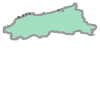

In [8]:
response_df_geo.iloc[5].geometry

In [15]:
response_df_geo.columns

Index(['impactType', 'impactValue', 'impactUnit', 'impactValueFlag',
       'location', 'startYear', 'startMonth', 'startDay', 'endYear',
       'endMonth', 'endDay', 'hazards', 'impactsAnnotation', 'appealCode',
       'country_kw', 'reportDate', 'disasterType', 'nathaz_text', 'country',
       'locationLowestAdmin', 'geocoding_flag', 'geometry'],
      dtype='object')

In [9]:
print(len(response_df))
print(len(response_df_geo.loc[response_df_geo.geometry==None]))

2032
1496


In [11]:
print(len(response_df_geo.loc[response_df_geo.country=='None']))

0


In [ ]:
response_df_geo = geocode_df_to_polygon(response_df, DATA_OUT_LLMS=DATA_OUT_LLMS, res_savename=res_savename)

/home/lhasbini/como_school/como_project4/src/geocoding.py:104: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = choices[choices[level_name].str.contains(target_name, na=False)]
/home/lhasbini/como_school/como_project4/src/geocoding.py:104: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = choices[choices[level_name].str.contains(target_name, na=False)]
/home/lhasbini/como_school/como_project4/src/geocoding.py:104: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = choices[choices[level_name].str.contains(target_name, na=False)]
/home/lhasbini/como_school/como_project4/src/geocoding.py:104: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, us

In [3]:
###### FILE PATHS
#fig_path = '/home/lhasbini/como_school/figure/'
#file_path_save = '/scratchx/lhasbini/como_school/'
json_file = DATA_IN_JSONS +'filtered_report_types_nat_hazards_summary-header.json'

##### Open and read the JSON file
with open(json_file, 'r') as json_file:
    filtered_reports = json.load(json_file)

# #### EXAMPLE OF LABELLED REPORTS
# df_labelled = pd.read_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_laura.csv')
# df_labelled_luca = pd.read_csv(DATA_LABELLED+'labelled_reports_luca.csv', index_col=0)

In [21]:
# df_labelled_luca["hazardSubtypes"] = df_labelled_luca["hazardSubtypes"].apply(
#     lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else [x]
# )
# # Use explode to create multiple rows
# df_labelled_luca = df_labelled_luca.explode("hazardSubtypes", ignore_index=True)

In [4]:
# Convert the labelled examples to chat format
# df_labelled_chat = convert_labelled_chat_format(df_labelled)
# df_labelled_chat.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_laura.csv', encoding='utf-8', index=False)

df_labelled_laura = pd.read_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_laura.csv', encoding='utf-8')
df_labelled_laura = df_labelled_laura.replace({np.nan: None})

# df_labelled_luca_chat = convert_labelled_chat_format(df_labelled_luca)
# df_labelled_luca_chat.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_luca.csv', encoding='utf-8', index=False)
df_labelled_luca = pd.read_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_luca.csv', encoding='utf-8')
df_labelled_luca = df_labelled_luca.replace({np.nan: None})

In [6]:
df_labelled_laura_geo = geocoding_reports_region_cities(df_labelled_laura)
df_labelled_luca_geo = geocoding_reports_region_cities(df_labelled_luca)

In [9]:
# df_labelled_laura_geo.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_geocoding_laura.csv', encoding='utf-8', index=False)
# df_labelled_luca_geo.to_csv(DATA_LABELLED+'labelled_example_haz-subtype-emdat_chat-format_geocoding_luca.csv', encoding='utf-8', index=False)

In [31]:
reports_chat = pd.read_csv(DATA_OUT_LLMS+"labelled_reports_response_llm_levels_haz_types_subtypes_impacts.csv", index_col=0)

In [32]:
# # reports_chat = reports_chat.replace({np.nan: None})
reports_chat[['region', 'state', 'city']] = reports_chat[['region', 'state', 'city']].apply(lambda x: x.apply(separate_locs))
# reports_chat[['region', 'state', 'city']] = reports_chat[['region', 'state', 'city']].apply(lambda x: x.apply(remove_startspace))
# reports_chat['region'] = reports_chat.apply(lambda row: [item for item in (row['region'] or []) + (row['state'] or []) if item is not None], axis=1)
# reports_chat = reports_chat.drop('state', axis=1)
# reports_chat = clean_chat_format(reports_chat)
# reports_chat_geo = geocoding_reports_region_cities(reports_chat)

In [29]:
# reports_chat_geo.to_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv', encoding='utf-8', index=False)

In [69]:
#Report chat with impact 
reports_chat_impact = pd.read_csv(DATA_OUT_LLMS+"llm_response_impact-based_quant_test.csv", index_col=0)

In [70]:
#Convert to good format 
columns_split = ["location", "hazards"]
for column in columns_split :
    reports_chat_impact[column] = reports_chat_impact[column].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else np.nan)

In [71]:
file_path = DATA_IN_JSONS +'filtered_report_types_nat_hazards_summary-header.json'#'nathaz_ifrc_reports_info_processed.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    ifrc_reports_processed = json.load(json_file)
ifrc_reports_df = pd.DataFrame(ifrc_reports_processed)
ifrc_reports_df = ifrc_reports_df.rename({"location" : "country"}, axis=1)

#Filther the reports 
ifrc_reports_df_impact = ifrc_reports_df.loc[ifrc_reports_df.appealCode.isin(reports_chat_impact.appealCode.unique())]
reports_chat_impact = pd.merge(reports_chat_impact, ifrc_reports_df_impact[["appealCode", "country"]], on = ["appealCode"], how="right")

In [77]:
#Perform geocoding 
reports_chat_impact_geocoding = geocoding_impact_location(reports_chat_impact)

In [83]:
reports_chat_impact_geocoding.to_csv(DATA_OUT_LLMS+"llm_response_impact-based_quant_test_geocoding.csv")

In [16]:
f"Information about location is found for {100*len(df_labelled_laura_geo)/len(df_labelled_laura)}% of the rows - Laura's labelling"

0.9477611940298507

In [ ]:
f"Information about location is found for {100*len(df_labelled_luca_geo)/len(df_labelled_luca)}% of the rows - Luca's labelling"

In [ ]:
f"Information about location is found for {100*len(reports_chat_geo)/len(reports_chat)}% of the rows - LLM output"

## Plot for a report with multi-hazard

In [73]:
appeal_test = "MDRUG050"
df_labelled_test = df_labelled_chat.loc[df_labelled_chat.appealCode == appeal_test]
df_labelled_test_geo = geocoding_reports_region_cities(df_labelled_test)

WRONG location Islamic University in Uganda, Main Campus;Islamic University of Uganda for eastern, similarity = 0.08571428571428574
CORRECT location Mbale for Mbale, similarity = 1.0
CORRECT location Kapchorwa for Kapchorwa, similarity = 1.0
CORRECT location Bulambuli for Bulambuli, similarity = 1.0
CORRECT location Bukedea for Bukedea, similarity = 1.0
CORRECT location Butaleja for Butaleja, similarity = 1.0
CORRECT location Sironko for Sironko, similarity = 1.0
CORRECT location Bududa for Bududa, similarity = 1.0
CORRECT location Namisindwa for Namisindwa, similarity = 1.0
CORRECT location Ntoroko for Ntoroko, similarity = 1.0
CORRECT location Mbale for Mbale, similarity = 1.0
CORRECT location Kapchorwa for Kapchorwa, similarity = 1.0
CORRECT location Bulambuli for Bulambuli, similarity = 1.0
CORRECT location Bukedea for Bukedea, similarity = 1.0
CORRECT location Butaleja for Butaleja, similarity = 1.0
CORRECT location Sironko for Sironko, similarity = 1.0
CORRECT location Bududa for

In [79]:
df_all_locs = {}
for hazard in df_labelled_test_geo.hazardType.unique() : 
    df_labelled_test_geo_haz = df_labelled_test_geo.loc[df_labelled_test_geo.hazardType == hazard]
    df_all_locs[hazard] = gpd.GeoDataFrame(df_labelled_test_geo_haz, geometry=gpd.points_from_xy(df_labelled_test_geo_haz.longitude, df_labelled_test_geo_haz.latitude))

In [106]:
dict_color = {"Flood" : "blue", "Storm" : "purple", "Mass movement" : "brown"}
dict_marker = {
    "Flood": "o",         # Circle
    "Earthquake": "s",    # Square
    "Mass movement": "^",     # Triangle
    "Storm": "*",         # Diamond
    "Drought": "p",       # Pentagon
    "Wildfire": "v",      # Star
}

In [107]:
def add_jitter(coords, scale=0.05):
    return coords + np.random.uniform(-scale, scale, size=coords.shape)

/tmp/ipykernel_446355/2251173517.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


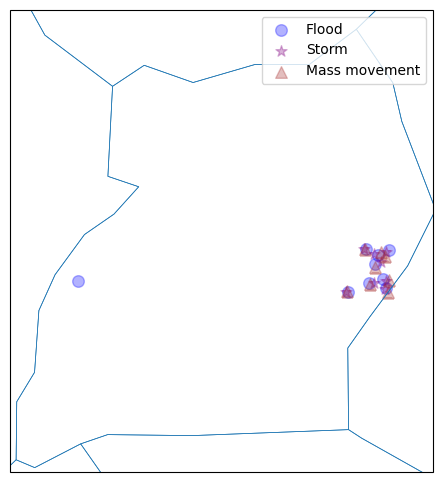

In [116]:
f, axes = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(6, 6))
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.boundary.plot(ax=axes, linewidth=0.5)
for hazard in df_all_locs.keys() : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    x_values = add_jitter(df_all_locs[hazard].geometry.x)
    y_values = add_jitter(df_all_locs[hazard].geometry.y)
    
    axes.scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3, label=hazard
    )

# Set the focus on Uganda
axes.set_xlim([29.5, 35])  # Longitude limits
axes.set_ylim([-1.5, 4.5])  # Latitude limits
axes.legend(fontsize=10)

plt.show()